In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub

path = kagglehub.dataset_download("gti-upm/leapgestrecog")

print(path)

100%|██████████| 2.13G/2.13G [00:24<00:00, 93.0MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/gti-upm/leapgestrecog/versions/1


In [3]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print(dirs)
    break

/root/.cache/kagglehub/datasets/gti-upm/leapgestrecog/versions/1
['leapGestRecog', 'leapgestrecog']


In [4]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/gti-upm/leapgestrecog/versions/1/leapGestRecog"

print(os.listdir(dataset_path))

['01', '09', '00', '06', '02', '05', '08', '07', '04', '03']


In [5]:
import os

print(os.listdir(dataset_path + "/00"))

['02_l', '08_palm_moved', '06_index', '09_c', '04_fist_moved', '03_fist', '05_thumb', '01_palm', '07_ok', '10_down']


In [8]:
import os
import cv2
import numpy as np

IMG_SIZE = 64

images = []
labels = []

gesture_names = []

for subject in os.listdir(dataset_path):

    subject_path = os.path.join(dataset_path, subject)

    if not os.path.isdir(subject_path):
        continue

    for gesture in os.listdir(subject_path):

        gesture_path = os.path.join(subject_path, gesture)

        if gesture not in gesture_names:
            gesture_names.append(gesture)

        label = gesture_names.index(gesture)

        count = 0

        for img in os.listdir(gesture_path):

            img_path = os.path.join(gesture_path, img)

            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if image is None:
                continue

            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

            image = image / 255.0

            images.append(image)

            labels.append(label)

            count += 1
            if count == 200:
                break

In [9]:
X = np.array(images)

y = np.array(labels)

print(X.shape)
print(y.shape)

(20000, 64, 64)
(20000,)


In [10]:
X = X.reshape(-1, 64, 64, 1)

print(X.shape)

(20000, 64, 64, 1)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(16000, 64, 64, 1)
(4000, 64, 64, 1)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(len(gesture_names), activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,914 (2.61 MB)

 Trainable params: 683,914 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 137s 270ms/step - accuracy: 0.8577 - loss: 0.4244 - val_accuracy: 0.9970 - val_loss: 0.0098
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 128s 242ms/step - accuracy: 0.9854 - loss: 0.0426 - val_accuracy: 0.9985 - val_loss: 0.0051
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 120s 240ms/step - accuracy: 0.9905 - loss: 0.0273 - val_accuracy: 0.9995 - val_loss: 0.0037
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 235ms/step - accuracy: 0.9933 - loss: 0.0223 - val_accuracy: 0.9995 - val_loss: 0.0059
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 118s 236ms/step - accuracy: 0.9927 - loss: 0.0197 - val_accuracy: 0.9995 - val_loss: 0.0045
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 239ms/step - accuracy: 0.9953 - loss: 0.0158 - val_accuracy: 0.9998 - val_loss: 0.0036
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 241ms/step - accuracy: 0.9973 - loss: 0.0092 - val_accuracy: 0.9998 - val_loss: 0.0023
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 235ms/step - accuracy: 0.9958 -

In [15]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.9998 - loss: 0.0042
Test Accuracy: 0.999750018119812


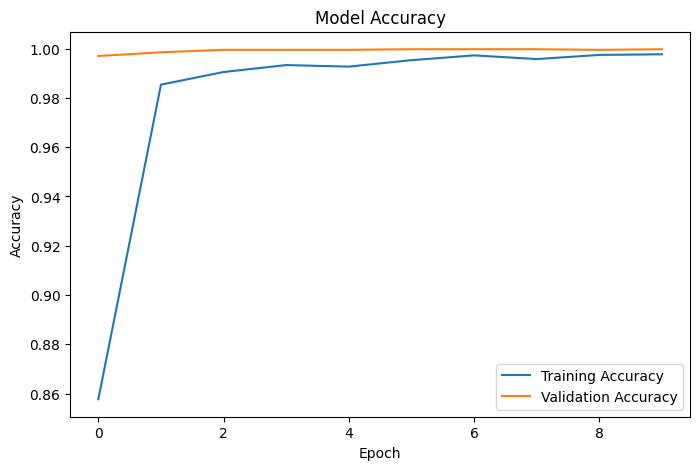

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

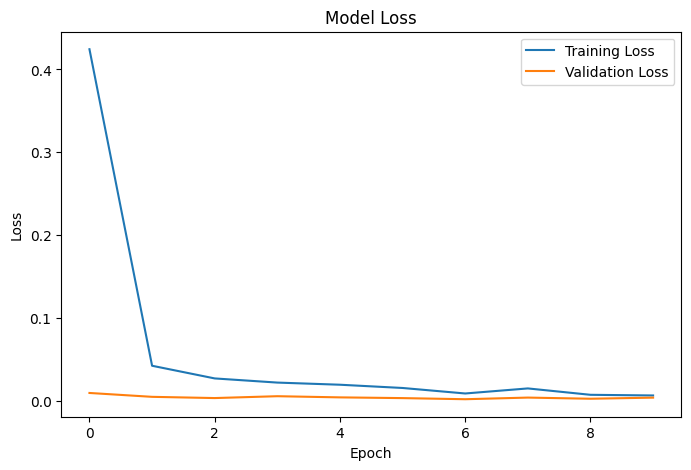

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

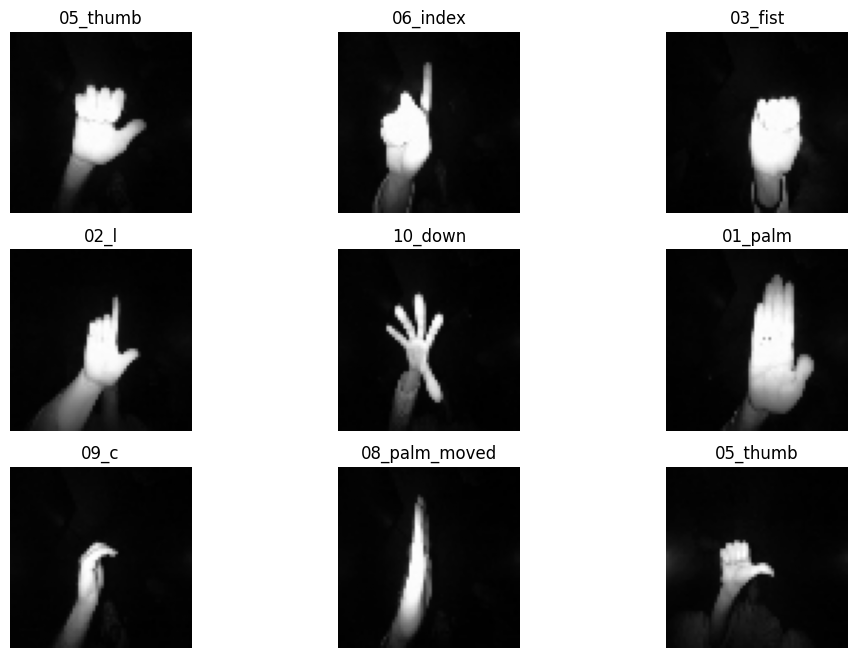

In [18]:
import numpy as np

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i].reshape(64,64), cmap='gray')

    pred = np.argmax(model.predict(X_test[i].reshape(1,64,64,1), verbose=0))

    plt.title(gesture_names[pred])

    plt.axis("off")

plt.show()